# SHOW THE CONTINUITY OF VARIATIONAL AUTOENCODERS LATENT SPACE

#### LIBRARIES

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from time import time
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import torch
import torch.nn as nn 
import torch.nn.functional as F 
import torchvision.transforms.functional as TF
import torchvision 
import torch.utils.data as data
import torch.distributions as dist
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

#### DATA RETRIVING, DATALOADER DEFINITION AND SHAPE CONTROL

Definisco sia il dataloader per allenare i Vae e Ae che il test e train lloader per il classificatore
I dati sono immagini in scala di grigi 28x28 rinormalizzati tra [0,1]. Vado a prendere una Batch di 15 elementi. 

In [3]:
BATCH_SIZE = 15
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
datas = torchvision.datasets.MNIST(root='./data', train= True, download= True, transform= torchvision.transforms.ToTensor())
dataloader = data.DataLoader(datas, batch_size= BATCH_SIZE, shuffle= True)
print('DIMENSIONS CONTROLL FOR DATALOADER:')
print("Single image dimensions:", datas.data[0].shape)
for images, labels in dataloader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break
for batch in dataloader:
    img, _ = batch
    print(img.min().item(), img.max().item(),"\n")
    break

BATCH_SIZE = 128
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))  # Normalizzazione con media e deviazione standard
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(testset, BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, BATCH_SIZE, shuffle=False)

print('DIMENSIONS CONTROLL FOR TRAINLOADER:')
for images, labels in trainloader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break
for batch in trainloader:
    img, _ = batch
    print(img.min().item(), img.max().item(), "\n")
    break

print('DIMENSIONS CONTROLL FOR TESTLOADER:')
for images, labels in testloader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break
for batch in testloader:
    img, _ = batch
    print(img.min().item(), img.max().item(), "\n")
    break

DIMENSIONS CONTROLL FOR DATALOADER:
Single image dimensions: torch.Size([28, 28])
Image batch dimensions: torch.Size([15, 1, 28, 28])
Image label dimensions: torch.Size([15])
0.0 1.0 

DIMENSIONS CONTROLL FOR TRAINLOADER:
Image batch dimensions: torch.Size([128, 1, 28, 28])
Image label dimensions: torch.Size([128])
-1.0 1.0 

DIMENSIONS CONTROLL FOR TESTLOADER:
Image batch dimensions: torch.Size([128, 1, 28, 28])
Image label dimensions: torch.Size([128])
-1.0 1.0 



## 1. MODELS DEFINITION AND FIRST LOOK

### LOSSES FUNCTIONS

In [4]:
def Normal_loss(x, b, recon_x, mu, logvar):
    #calculated with close form
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + b * KLD

def KLD_t_student_mc(q: dist.StudentT, p: dist.StudentT, n_samples=10000):
    #calculated with montecarlo approximation
    samples = q.rsample((n_samples,))
    log_q = q.log_prob(samples)
    log_p = p.log_prob(samples)
    return torch.mean(log_q - log_p)

def t_di_student_loss(x, b, x_rec, df1, loc1, scale1, df2, loc2 = 0, scale2 = 1):
    #calculated with montecarlo approximation
    q = dist.StudentT(df=torch.full_like(loc1, df1), loc=loc1, scale=scale1, validate_args=False)
    p = dist.StudentT(df=torch.full_like(torch.as_tensor(loc2, dtype=loc1.dtype, device=loc1.device), df2), loc=loc2, scale=scale2, validate_args=False)
    BCE = F.binary_cross_entropy(x_rec, x, reduction='sum')
    KLD = KLD_t_student_mc(q,p)
    return BCE + b * KLD

class PerceptualLoss(nn.Module):
    def __init__(self, layers=(3, 8, 15)):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features
        self.vgg_layers = vgg[:max(layers) + 1].eval()
        for param in self.vgg_layers.parameters():
            param.requires_grad = False
        self.selected_layers = layers

        # Normalizzazione come per ImageNet
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

    def forward(self, x, y):
        # MNIST: [B,1,28,28] → RGB [B,3,28,28] → resize [B,3,224,224]
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
            y = y.repeat(1, 3, 1, 1)

        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        y = F.interpolate(y, size=(224, 224), mode='bilinear', align_corners=False)

        # Normalizzazione
        x = (x - self.mean.to(x.device)) / self.std.to(x.device)
        y = (y - self.mean.to(y.device)) / self.std.to(y.device)

        loss = 0.0
        for i, layer in enumerate(self.vgg_layers):
            x = layer(x)
            y = layer(y)
            if i in self.selected_layers:
                loss += F.l1_loss(x, y)

        return loss

def combined_perceptual_loss(x, b, recon, extractor, other_fn, mu, logvar, alpha=1.0, beta=0.1):
    x = x.repeat(1, 3, 1, 1)
    recon = recon.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
    recon = F.interpolate(recon, size=(224, 224), mode='bilinear', align_corners=False)

    x_feat = extractor(x)
    recon_feat = extractor(recon)
    perceptual_loss = sum(F.l1_loss(rf, xf) for rf, xf in zip(recon_feat, x_feat))
    
    other_loss = other_fn(x, b, recon, mu, logvar)
    return alpha * other_loss + beta * perceptual_loss

def sample_gumbel(shape, eps=1e-20):
    U = torch.rand(shape)
    return -torch.log(-torch.log(U + eps) + eps)

def gumbel_softmax_sample(logits, tau):
    gumbel_noise = sample_gumbel(logits.shape).to(logits.device)
    y = logits + gumbel_noise
    return F.softmax(y / tau, dim=-1)

def gumbel_softmax(logits, tau=1.0, hard=False):
    y_soft = gumbel_softmax_sample(logits, tau)
    if hard:
        # Straight-through trick
        index = y_soft.max(dim=-1, keepdim=True)[1]
        y_hard = torch.zeros_like(y_soft).scatter_(-1, index, 1.0)
        return (y_hard - y_soft).detach() + y_soft
    else:
        return y_soft

def gumbel_vae_loss(x, x_recon, logits):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    q_y = F.softmax(logits, dim=-1)
    log_q_y = F.log_softmax(logits, dim=-1)
    kl_div = torch.sum(q_y * (log_q_y - torch.log(torch.tensor(1.0 / q_y.size(-1)))), dim=-1)
    kl_div = kl_div.sum()

    return recon_loss + kl_div


### MODELS: VAE AND CLASSIFICATOR

In [5]:
class CNN_predictor(nn.Module):
    def __init__(self):
        super(CNN_predictor,self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),#Nx32x26x26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 3, stride=3),#Nx32x8x8
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),#Nx16x6x6
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*6*6, 64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self, x):
        out = self.network(x)
        return out

class AE(nn.Module):
    def __init__(self):
        super(AE,self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2,16),
            nn.Tanh(),
            nn.Linear(16,64),
            nn.Tanh(),
            nn.Linear(64,28*28),
            nn.Unflatten(1,(1,28,28))
        )
    
    def forward(self,x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec, enc

class Normal_VAE(nn.Module):
    def __init__(self, h_dim = 20, z_dim = 2):
        super(Normal_VAE, self).__init__()
        self.img_h = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3), #N 26 x 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride=2), # N 
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*11*11, 64),
            nn.ReLU(),
            nn.Linear(64, h_dim))
        
        self.z_mu = nn.Linear(h_dim, z_dim)
        self.z_sigma = nn.Linear(h_dim, z_dim)
        self.sampling = nn.Linear(z_dim, h_dim)

        self.h_img = nn.Sequential(
            nn.Linear(h_dim, 64),
            nn.ReLU(),
            nn.Linear(64,16*11*11),
            nn.ReLU(),
            nn.Unflatten(1,(16,11,11)),
            nn.ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3),
            nn.Sigmoid()
        )

    def encode(self,x):
        h = self.img_h(x)
        return self.z_mu(h) , self.z_sigma(h)
    
    def decode(self,z):
        h = self.sampling(z)
        return self.h_img(h)

    def reparametrize(self, mu, lg_s):
        sd = torch.exp(0.5 * lg_s)
        eps = torch.randn_like(lg_s)
        return mu + eps * sd
    
    def forward(self, x):
        mu, logs = self.encode(x)
        z = self.reparametrize(mu,logs)
        x_recon = self.decode(z)
        
        return x_recon, mu, logs, z

class Normal_VAE_extended(nn.Module):
    def __init__(self, h_dim = 20, z_dim = 2):
        super(Normal_VAE_extended, self).__init__()
        
        self.img_h = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),
            nn.LayerNorm([16, 11, 11]),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16 * 11 * 11, 1000),
            nn.ReLU(),
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Linear(500, 200),
            nn.LayerNorm(200),
            nn.ReLU()
        )

        
        self.z_mu = nn.Linear(h_dim, z_dim)
        self.z_sigma = nn.Linear(h_dim, z_dim)
        self.sampling = nn.Linear(z_dim, h_dim)

        self.h_img = nn.Sequential(
            nn.Linear(h_dim, 64),
            nn.Linear(64,200),
            nn.ReLU(),
            nn.Linear(200,500),
            nn.ReLU(),
            nn.Linear(500,1000),
            nn.ReLU(),
            nn.Linear(1000,16*11*11),
            nn.ReLU(),
            nn.Unflatten(1,(16,11,11)),
            nn.ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3),
            nn.Sigmoid()
        )

    def encode(self,x):
        h = self.img_h(x)
        return self.z_mu(h) , self.z_sigma(h)
    
    def decode(self,z):
        h = self.sampling(z)
        return self.h_img(h)

    def reparametrize(self, mu, lg_s):
        sd = torch.exp(0.5 * lg_s)
        eps = torch.randn_like(lg_s)
        return mu + eps * sd
    
    def forward(self, x):
        
        mu, logs = self.encode(x)
        z = self.reparametrize(mu,logs)
        x_recon = self.decode(z)
        
        return x_recon, mu, logs, z

class T_student_VAE(nn.Module):
    def __init__(self, df, h_dim = 200, z_dim = 20):
        super(T_student_VAE, self).__init__()
        self.img_h = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3), #N 26 x 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride=2), # N 
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*11*11, 64),
            nn.ReLU(),
            nn.Linear(64, h_dim))
        
        self.z_loc = nn.Linear(h_dim, z_dim)
        self.z_scale = nn.Linear(h_dim, z_dim)
        self.sampling = nn.Linear(z_dim, h_dim)

        self.h_img = nn.Sequential(
            nn.Linear(h_dim, 64),
            nn.ReLU(),
            nn.Linear(64,16*11*11),
            nn.ReLU(),
            nn.Unflatten(1,(16,11,11)),
            nn.ConvTranspose2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3),
            nn.Sigmoid()
        )

        self.df = df
    
    def encode(self,x):
        h = self.img_h(x)
        return self.df, self.z_loc(h), self.z_scale(h)
    
    def decode(self,z):
        h = self.sampling(z)
        return self.h_img(h)
    
    def reparametrize(self, df, loc, scale):
        #reparametrization based on
        #z=loc+scale x N(0,1)/rad(χ2(df)/df)
        Normal = torch.randn_like(loc)
        gamma = torch.distributions.Gamma(df/2,1/2).sample(loc.shape)
        chi2 = 2 * gamma
        return loc + scale*Normal/(torch.sqrt(chi2/df))
    
    def forward(self,x):
        df, loc, scale = self.encode(x)
        scale = torch.exp(scale)
        z = self.reparametrize(df, loc, scale)
        x_recon = self.decode(z)
        return x_recon, self.df, loc, scale, self.df, z

class Feature_extractor(nn.Module):

    #works with sequential defined nets
    def __init__(self, cnn_model, layers):
        super(Feature_extractor,self).__init__()
        self.features = []
        for i,layer in enumerate(layers):
            self.features.append(nn.Sequential(*list(cnn_model.children())[:layer]))

    def forward(self,x):
        out = []
        for feature in self.features:
            out.append(feature(x))
        return out

class Denoising_AE(nn.Module):
    def __init__(self):
        super(Denoising_AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=1, padding=1 ),  # B, 16, H/2, W/2
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), # B, 32, H/4, W/4
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=3),
            nn.Conv2d(32,64,3, stride=1, padding=1)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,3,stride=1, padding=1),
            nn.Upsample(size=(28,28), mode='bilinear'),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=1, padding=1),
            nn.Sigmoid()
        )
    def forward(self,x):
        z = self.encoder(x)
        return self.decoder(z), z

class GumbelVAE(nn.Module):
    def __init__(self, input_dim=784, n_discrete=10, n_categories=10, tau=0.05):
        super().__init__()
        self.n_discrete = n_discrete
        self.n_categories = n_categories
        self.tau = tau

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, n_discrete * n_categories)  # output size is bottleneck (flattened)
        )

        self.decoder = nn.Sequential(
            nn.Linear(n_discrete * n_categories, 8),
            nn.ReLU(),
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid(),
            nn.Unflatten(1,(1,28,28))
        )


    def encode(self, x):
        logits = self.encoder(x)
        logits = logits.view(-1, self.n_discrete, self.n_categories)
        return logits

    def reparameterize(self, logits, tau, hard=False):
        return gumbel_softmax(logits, tau, hard).view(-1, self.n_discrete * self.n_categories)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, tau=1.0, hard=False):
        logits = self.encode(x)
        z = self.reparameterize(logits, tau, hard)
        return self.decode(z), logits

### TRAINING AND SUPPORT FUNCTIONS

In [6]:
#Functions for the vae model
def train_percept_Vae(dataloader, N_epochs, model, criterion, optimizer, b = 1, predictor = None, layers = 0, scheduler = None, other_criterion = None, epoch_range = 1,best_loss = float('inf')):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
        
    #definisco l'estrattore delle feature per la perceptual loss
    if predictor is None:
        raise Exception('Predittore non definito')
    if other_criterion not in [Normal_loss, t_di_student_loss]:
        raise Exception("Altra Looss passata alla perceptual loss non definita")
    extractor = Feature_extractor(predictor, layers).eval().to(device)
    Losses = []
    start = time()

    for epoch in tqdm(range(N_epochs),desc='Epochs'):
        model.train()
        Tr_current_loss = 0.0

        for i,(img,lab) in enumerate(dataloader):
            img = img.to(device)
            lab = lab.to(device)

            args = model(img)
            assert torch.all(img >= 0) and torch.all(img <= 1), "img fuori range"
            assert torch.all(args[0] >= 0) and torch.all(args[0] <= 1), "recon fuori range"

            mu, logvar = args[1], args[2]
            loss = criterion(img, b, args[0], extractor, other_criterion, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            Tr_current_loss += loss.item()
        
        if Tr_current_loss/i < best_loss:
            torch.save(model.state_dict(),'temporary_VAE.pth')
            #print(f'Saved epoch: {epoch}')
            best_loss = Tr_current_loss/i

        Losses.append(Tr_current_loss/i)

        if scheduler is not None:
            scheduler.step(loss.item()/i)

        if (epoch+1)%epoch_range == 0.0:
            print(f'Epoch: {epoch+1} | Loss: {Tr_current_loss/i:.4f} | Time: {time()-start:.2f}')
            start = time()
    return Losses, best_loss

def train_G_Vae(dataloader, N_epochs, model, criterion, optimizer, scheduler = None, epoch_range = 1,best_loss = float('inf')):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    Losses = []
    start = time()

    for epoch in range(N_epochs):
        model.train()
        Tr_current_loss = 0.0

        for i,(img,lab) in tqdm(enumerate(dataloader), desc='batch'):
            img = img.to(device)
            lab = lab.to(device)

            args = model(img)
            assert torch.all(img >= 0) and torch.all(img <= 1), "img fuori range"
            assert torch.all(args[0] >= 0) and torch.all(args[0] <= 1), "recon fuori range"

            optimizer.zero_grad()
            loss = criterion(img, *args)
            loss.backward()
            optimizer.step()
            Tr_current_loss += loss.item()
        
        if Tr_current_loss/i < best_loss:
            torch.save(model.state_dict(),'temporary_VAE.pth')
            #print(f'Saved epoch: {epoch}')
            best_loss = Tr_current_loss/i

        Losses.append(Tr_current_loss/i)

        if scheduler is not None:
            scheduler.step(Tr_current_loss/i)

        if (epoch+1)%epoch_range == 0.0:
            print(f'Epoch: {epoch+1} | Loss: {Tr_current_loss/i:.4f} | Time: {time()-start:.2f}')
            start = time()
    return Losses, best_loss

def train_Vae(dataloader, N_epochs, model, criterion, optimizer, b = 1, scheduler = None, epoch_range = 1,best_loss = float('inf')):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    Losses = []
    start = time()

    for epoch in range(N_epochs):
        model.train()
        Tr_current_loss = 0.0

        for i,(img,lab) in tqdm(enumerate(dataloader), desc='batch'):
            img = img.to(device)
            lab = lab.to(device)

            args = model(img)
            assert torch.all(img >= 0) and torch.all(img <= 1), "img fuori range"
            assert torch.all(args[0] >= 0) and torch.all(args[0] <= 1), "recon fuori range"

            optimizer.zero_grad()
            loss = criterion(img,b, *args[:-1])
            loss.backward()
            optimizer.step()
            Tr_current_loss += loss.item()
        
        if Tr_current_loss/i < best_loss:
            torch.save(model.state_dict(),'temporary_VAE.pth')
            #print(f'Saved epoch: {epoch}')
            best_loss = Tr_current_loss/i

        Losses.append(Tr_current_loss/i)

        if scheduler is not None:
            scheduler.step(Tr_current_loss/i)

        if (epoch+1)%epoch_range == 0.0:
            print(f'Epoch: {epoch+1} | Loss: {Tr_current_loss/i:.4f} | Time: {time()-start:.2f}')
            start = time()
    return Losses, best_loss

def img_vs_recon(model, dataloader):
    model.eval()
    imgs = torch.stack([dataloader.dataset[i][0] for i in range(9)])  
    recon = model(imgs)[0]

    plt.figure(figsize=(12,4))
    plt.gray()
    for i,item in enumerate(imgs):
        plt.subplot(2,9,i+1)
        item = item.reshape(-1,28,28)
        plt.imshow(item[0].detach().numpy())
        
    
    for i,item in enumerate(recon):
        plt.subplot(2,9,9+i+1)
        item = item.reshape(-1,28,28)
        plt.imshow(item[0].detach().numpy())

def scatter(model,dataloader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    axis_x = []
    axis_y = []
    answers = []
    with torch.no_grad():
        for img, labels in dataloader:
            model.eval()
            answers += labels.tolist()
            img = img.to(device)
            z = model(img)[-1]
            axis_x += z[:,0].tolist()
            axis_y += z[:,1].tolist()
    
    plt.scatter(axis_x, axis_y, c=answers, cmap='tab10')
    plt.colorbar()
    plt.show()

def scatter_3d(model, dataloader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    axis_x = []
    axis_y = []
    axis_z = []
    answers = []
    with torch.no_grad():
        for img, labels in dataloader:
            model.eval()
            answers += labels.tolist()
            img = img.to(device)
            z = model(img)[-1]
            axis_x += z[:,0].tolist()
            axis_y += z[:,1].tolist()
            axis_z += z[:,2].tolist()  # prendo la terza dimensione
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # crea asse 3D
    scatter = ax.scatter(axis_x, axis_y, axis_z, c=answers, cmap='tab10')
    fig.colorbar(scatter)
    plt.show()

def scatter_G(model, dataloader, max_samples=2000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    latent = []
    labels_all = []
    total_samples = 0

    model.eval()
    with torch.no_grad():
        for img, labels in dataloader:
            batch_size = img.size(0)
            if total_samples + batch_size > max_samples:
                remaining = max_samples - total_samples
                img = img[:remaining]
                labels = labels[:remaining]
                batch_size = remaining

            img = img.to(device)
            logits = model.encode(img)
            flattened = logits.view(batch_size, -1)
            latent.append(flattened.cpu())
            labels_all += labels.tolist()
            total_samples += batch_size

            if total_samples >= max_samples:
                break

    latent = torch.cat(latent, dim=0).numpy()

    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent)

    plt.figure(figsize=(8, 6))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels_all, cmap='tab10', alpha=0.5)
    plt.colorbar()
    plt.title(f"Latent Space PCA Projection ({max_samples} samples)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
def Vae_graphs(tr_loss,n_epochs):
    plt.plot(range(n_epochs),tr_loss,label='tr_loss', c='black')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

def plot_generate(model, z_dim, sample_size):
    z = torch.randn(sample_size, z_dim)
    model.eval()
    with torch.no_grad():
        generated = model.decode(z)
    
    fig, axes = plt.subplots(1, sample_size, figsize=(sample_size,1))
    for i in range(sample_size):
        axes[i].imshow(generated[i][0].detach().cpu(), cmap='gray')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def plt_interpolation(model, img1, img2, n_step = 10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    params1 = model.encode(img1)
    params2 = model.encode(img2)

    z1 = model.reparametrize(*params1)
    z2 = model.reparametrize(*params2)

    interpolated_z = torch.stack([ (1-alpha) * z1 + alpha * z2 for alpha in torch.linspace(0,1,steps = n_step)]).to(next(model.parameters()).device)
    interp_z = interpolated_z.squeeze(1)
    interp_x = interp_z[:, 0].cpu().detach().numpy()
    interp_y = interp_z[:, 1].cpu().detach().numpy()
    axis_x = []
    axis_y = []
    answers = []
    with torch.no_grad():
        for img, labels in dataloader:
            model.eval()
            answers += labels.tolist()
            img = img.to(device)
            z = model(img)[-1]
            axis_x += z[:,0].tolist()
            axis_y += z[:,1].tolist()
    
    plt.scatter(axis_x, axis_y, c=answers, cmap='tab10', alpha = 0.5)
    plt.colorbar()
    plt.plot(interp_x, interp_y, color='black', linewidth=1)
    plt.scatter(interp_x, interp_y, color='black', s=10, label='Punti interpolati', zorder=3)
    plt.show()

    with torch.no_grad():
        decoded_img = model.decode(interpolated_z.squeeze(1))

    fig, axes = plt.subplots(1,n_step, figsize=(n_step, 1.5))
    for i in range(n_step):
        axes[i].imshow(decoded_img[i].squeeze().cpu(), cmap='grey')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def plt_interpolation_G(model, img1, img2, dataloader, n_step=10, n_proj=2000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    # Ottieni z1 e z2 (Gumbel sample)
    with torch.no_grad():
        logits1 = model.encode(img1.to(device))
        logits2 = model.encode(img2.to(device))
        z1 = model.reparameterize(logits1, tau=1.0, hard=False)
        z2 = model.reparameterize(logits2, tau=1.0, hard=False)

        # Interpolazione lineare tra z1 e z2
        interpolated_z = torch.stack([
            (1 - alpha) * z1 + alpha * z2
            for alpha in torch.linspace(0, 1, steps=n_step)
        ]).squeeze(1).to(device)

        # Decodifica e mostra immagini interpolate
        decoded_img = model.decode(interpolated_z)
        fig, axes = plt.subplots(1, n_step, figsize=(n_step, 1.5))
        for i in range(n_step):
            axes[i].imshow(decoded_img[i].squeeze().cpu(), cmap='gray')
            axes[i].axis('off')
        plt.suptitle("Interpolazione nello spazio latente Gumbel")
        plt.tight_layout()
        plt.show()

    # Proiezione 2D per visualizzare interpolazione
    latents = []
    labels_all = []
    n_collected = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model.encode(x)
            z = model.reparameterize(logits, tau=1.0, hard=False)
            latents.append(z.cpu())
            labels_all.append(y)
            n_collected += x.size(0)
            if n_collected >= n_proj:
                break

    latents = torch.cat(latents, dim=0)[:n_proj]
    labels_all = torch.cat(labels_all, dim=0)[:n_proj]

    # Aggiungi anche i punti interpolati al TSNE
    full_z = torch.cat([latents, interpolated_z.cpu()], dim=0)
    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    z_2d = tsne.fit_transform(full_z)

    z_data_2d = z_2d[:n_proj]
    z_interp_2d = z_2d[n_proj:]

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(z_data_2d[:, 0], z_data_2d[:, 1], c=labels_all, cmap='tab10', alpha=0.5)
    plt.plot(z_interp_2d[:, 0], z_interp_2d[:, 1], color='black', linewidth=1.5, label='Interpolazione')
    plt.scatter(z_interp_2d[:, 0], z_interp_2d[:, 1], color='black', s=20)
    plt.legend()
    plt.title("Traiettoria nello spazio latente Gumbel (TSNE)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()

def get_random_sample_dataloader(dataset, n,batch_size=64):
    total_len = len(dataset)
    indices = np.random.permutation(total_len)
    third_len = total_len // n
    selected_indices = indices[:third_len]

    sampler = data.SubsetRandomSampler(selected_indices)
    dataloader = data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)

    return dataloader

def interactive_scatter_(model, dataloader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    axis_x = []
    axis_y = []
    answers = []

    with torch.no_grad():
        for img, labels in dataloader:
            answers += labels.tolist()
            img = img.to(device)
            z = model(img)[-1]
            axis_x += z[:, 0].tolist()
            axis_y += z[:, 1].tolist()

    fig, (ax_scatter, ax_img) = plt.subplots(1, 2, figsize=(10, 5))

    scatter_plot = ax_scatter.scatter(axis_x[:2000], axis_y[:2000], c=answers[:2000], cmap='tab10', alpha = 0.5)
    plt.colorbar(scatter_plot, ax=ax_scatter)
    #ax_scatter.set_xlim(-6, 6)
    #ax_scatter.set_ylim(-6, 6)
    ax_scatter.set_xlabel("Latent X")
    ax_scatter.set_ylabel("Latent Y")
    ax_scatter.set_title("Latent Space")

    # Inizializza l'immagine con uno spazio vuoto (bianco)
    blank_img = torch.zeros((28, 28))  # cambia dimensioni se diverso
    im = ax_img.imshow(blank_img, cmap='gray')
    ax_img.axis('off')
    ax_img.set_title("Ricostruzione")

    def on_mouse_move(event):
        if event.inaxes == ax_scatter and event.xdata is not None and event.ydata is not None:
            point = torch.tensor([[event.xdata, event.ydata]], dtype=torch.float32).to(device)

            with torch.no_grad():
                recon = model.decode(point)[0].cpu().squeeze()
                # se ha 3 dimensioni (es. 1x28x28) la riduco a 2D (28x28)
                if recon.dim() == 3:
                    recon = recon.squeeze(0)

            # Assicuro che la matrice sia 2D numpy array
            img_data = recon.numpy()

            # Aggiorno immagine con valori tra 0 e 1 (se necessario)
            im.set_data(img_data)
            im.set_clim(0, 1)  # imposta la scala colori da 0 a 1 (utile per MNIST)
            ax_img.set_title(f"Ricostruzione al punto ({event.xdata:.2f}, {event.ydata:.2f})")
            fig.canvas.draw_idle()

    fig.canvas.mpl_connect('motion_notify_event', on_mouse_move)
    plt.show()

def interactive_scatter_gumbel(model, dataloader, n_points=2000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    latents = []
    labels = []

    # Estrai rappresentazioni latenti Gumbel
    with torch.no_grad():
        n_collected = 0
        for x, y in dataloader:
            x = x.to(device)
            logits = model.encode(x)
            z = model.reparameterize(logits, tau=1.0, hard=False)
            latents.append(z.cpu())
            labels.append(y)
            n_collected += x.size(0)
            if n_collected >= n_points:
                break

    latents = torch.cat(latents, dim=0)[:n_points]
    labels = torch.cat(labels, dim=0)[:n_points]

    # Riduci in 2D con TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_2d = tsne.fit_transform(latents.numpy())

    fig, (ax_scatter, ax_img) = plt.subplots(1, 2, figsize=(10, 5))

    sc = ax_scatter.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', alpha=0.5)
    plt.colorbar(sc, ax=ax_scatter)
    ax_scatter.set_title("Spazio latente (proiezione TSNE)")
    ax_scatter.set_xlabel("Dim 1")
    ax_scatter.set_ylabel("Dim 2")

    # Immagine iniziale vuota
    blank_img = torch.zeros((28, 28))  # o altro formato
    im = ax_img.imshow(blank_img, cmap='gray')
    ax_img.axis('off')
    ax_img.set_title("Ricostruzione")

    def on_mouse_move(event):
        if event.inaxes == ax_scatter and event.xdata and event.ydata:
            # Trova il punto TSNE più vicino
            pos = torch.tensor([event.xdata, event.ydata])
            dists = torch.norm(torch.tensor(z_2d) - pos, dim=1)
            nearest_idx = torch.argmin(dists)

            # Prendi il vero z associato
            z_sample = latents[nearest_idx].unsqueeze(0).to(device)

            with torch.no_grad():
                recon = model.decode(z_sample)[0].cpu().squeeze()
                if recon.dim() == 3:
                    recon = recon.squeeze(0)
                img_data = recon.numpy()

            im.set_data(img_data)
            im.set_clim(0, 1)
            ax_img.set_title(f"Ricostruzione punto vicino ({event.xdata:.2f}, {event.ydata:.2f})")
            fig.canvas.draw_idle()

    fig.canvas.mpl_connect('motion_notify_event', on_mouse_move)
    plt.tight_layout()
    plt.show()

#Functions for the predictor model
def get_accuracy(logit, target):
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects / target.size(0)
    return accuracy.item()

def compute_weight_norm(model):
    norm = 0.0
    for name, param in model.named_parameters():
      if "weight" in name:
        norm += torch.norm(param.data, p= 2)
    return norm.cpu().item()

def get_batch_accuracy(logit, target):
    """Obtain accuracy for one batch of data"""
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects / target.size(0)
    return accuracy.item()

def get_test_acc(model,loader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc = 0.0
    for i, (images, labels) in enumerate(loader, 0):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        test_acc += get_batch_accuracy(outputs, labels)
    return test_acc/(i+1)

def get_test_loss(model, criterion, loader):

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_running_loss = 0
    for i, (images, labels) in enumerate(loader, 0):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels) 
        test_running_loss += loss.item()
    return test_running_loss/(i+1)

def train_classificator(model, num_epochs, trainloader, criterion, optimizer, val):

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    tr_losses = []
    te_losses = []
    tr_accs = []
    te_accs = []
    norms = []
    
    for epoch in range(num_epochs):
        train_running_loss = 0.0
        train_acc = 0.0
        model = model.train()
        start = time()
        ## training step
        for i, (images, labels) in enumerate(trainloader):
            
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()
            train_acc += get_accuracy(logits, labels)
        
        tr_losses.append(train_running_loss / i)
        tr_accs.append(train_acc/i)
        norms.append(compute_weight_norm(model))

        model.eval()
        te_ac = get_test_acc(model, val)
        te_l = get_test_loss(model, criterion, val)
        te_accs.append(te_ac)
        te_losses.append(te_l)
        print(f"Epoch: {epoch+1} | Train Loss: {train_running_loss / i:.4f} | Train Accuracy: {train_acc/i:.4f} | Test Loss:{te_l:.4f} | Test Accuracy {te_ac:.4f} | Time: {time()-start:.2f}") 
    return tr_losses, tr_accs, te_losses, te_accs, norms

def Predictor_graphs(tr_loss,tr_acc,te_loss,te_acc,n_epochs):
    fig,ax = plt.subplots(1,2,figsize=(15,7))
    ax[0].plot(range(n_epochs),tr_loss,label='tr_loss', c='black')
    ax[0].plot(range(n_epochs),te_loss,label='te_loss', c='#C99700')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Test vs Train Loss')

    ax[1].plot(range(n_epochs),tr_acc,label='tr_loss', c='black')
    ax[1].plot(range(n_epochs),te_acc,label='te_loss', c='#C99700')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Test vs Train Accuracy')

    ax[0].legend()
    ax[1].legend()

def make_con_matrix(model, testloader):

    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    model.eval()
    y_true = []
    y_pred = []

    for image, label in testloader:
        y_true.extend(label.numpy())
        outs = model(image)
        outes = torch.max(outs,1)[1]
        y_pred.extend(outes.numpy())

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
    plt.xlabel("Predicted labels")
    plt.ylabel("True labels")
    plt.title("Confusion Matrix")
    plt.show()

def train_denoiser(data, denoised_data, N_epochs, model, optimizer, criterion, batch_size):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    Losses = []
    start = time()
    num_total_samples = len(denoised_data)


    for epoch in range(N_epochs):
        model.train()
        Tr_current_loss = 0.0

        for (noisy_batch, _), (target_batch, _) in zip(data, denoised_data):

            noisy_batch = noisy_batch.to(device)
            target_batch = target_batch.to(device)

            args = model(noisy_batch)
            assert torch.all(noisy_batch >= 0) and torch.all(noisy_batch <= 1), "img fuori range"
            assert torch.all(args[0] >= 0) and torch.all(args[0] <= 1), "recon fuori range"

            loss = criterion(args[0], target_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            Tr_current_loss += loss.item()

        Losses.append(Tr_current_loss/(num_total_samples/batch_size))
        print(f'Epoch: {epoch+1} | Loss: {Tr_current_loss/(num_total_samples/batch_size):.4f} | Time: {time()-start:.2f}')
        start = time()
    return Losses

### RESULTS FOR GAUSSIAN PRIOR
Qua andiamo a vedere i risultati per una rete che utilizza una gaussiana come prior. Si dara uno sguardo a spazi latenti molto piccoli, 2/3, per mostrare come anche rimpicciolendo molto lo spazio delle feature, da 28*28 -> 2/3, manteniamo una buona rappresentazione e troviamo la continuità. Sarà fatta poi una prova con uno spazio latente molto più grande con 50 variabii latenti.

-spazio latente bi-dimensionale

In [6]:
model = Normal_VAE(200,2)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
criterion = lambda x, b, recon, extractor, other_fn, mu, logvar: combined_perceptual_loss(x, b, recon, extractor, other_fn, mu, logvar, alpha=1.0, beta=0.1)
predictor = models.vgg16(pretrained=True).features[:16]

C:\Users\pitom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pitom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
losses, best = train_percept_Vae(dataloader=dataloader,N_epochs=20,model=model,criterion=criterion,optimizer=optimizer,b=0.1,predictor=predictor,layers=[8], other_criterion=Normal_loss, epoch_range=1)
Vae_graphs(losses, N_epochs)

purtroppo uno spazio latente cosi basso non è soddisfacente nelle ricostruzioni

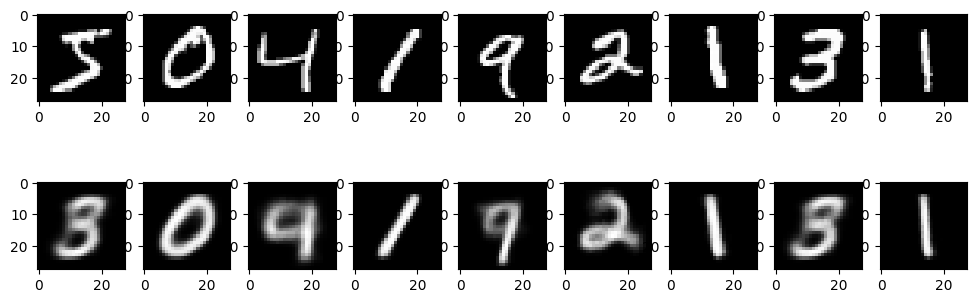

In [9]:
img_vs_recon(model, dataloader)

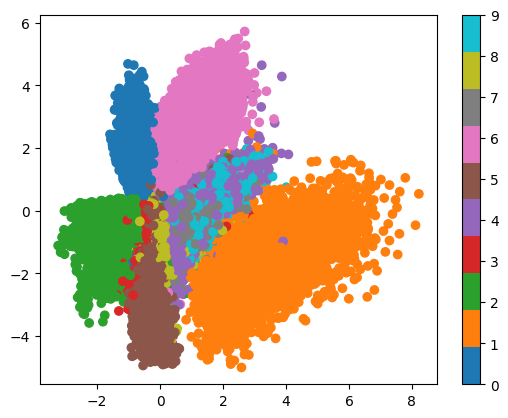

In [ ]:
scatter(model,dataloader)

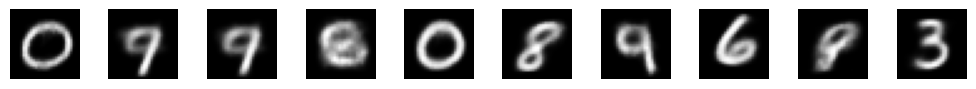

In [ ]:
plot_generate(model, 2, 10)

In [6]:
model = Normal_VAE(200,2)
model.load_state_dict(torch.load('200_2_Normal_Vae.pth'))

<All keys matched successfully>

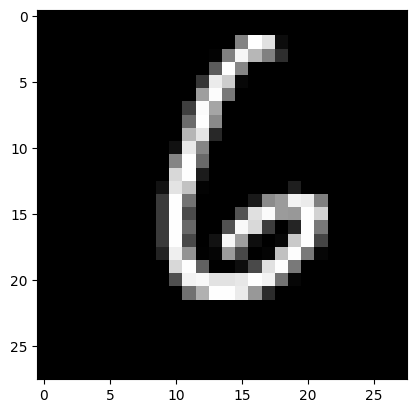

In [42]:
x = dataloader.dataset.data[32].unsqueeze(0).unsqueeze(0).float() / 255.0
plt.imshow(x[0,0].detach().numpy(), cmap='gray')

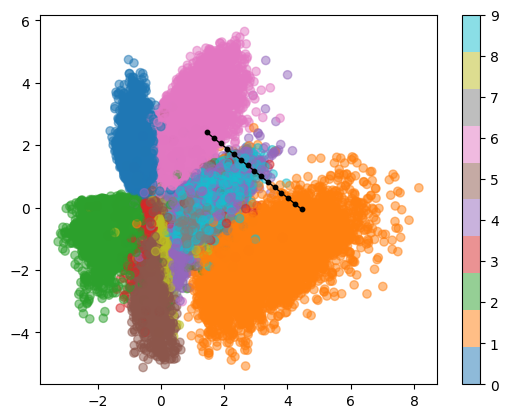

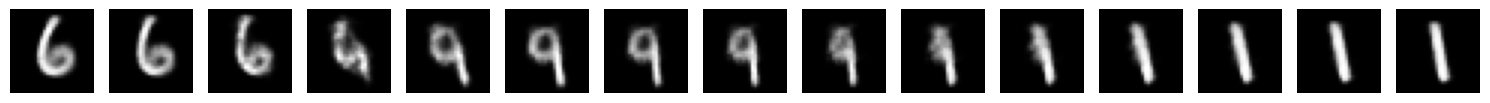

In [ ]:
x = dataloader.dataset.data[32].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[6].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y, n_step=15)

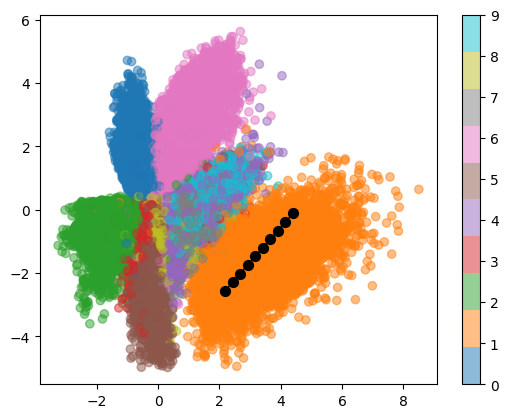

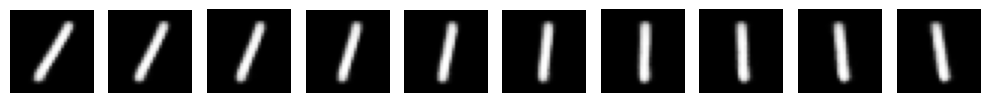

In [13]:
x = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[6].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y, n_step=10)

-spazio latente tri-dimensionale

In [7]:
model = Normal_VAE(200,3)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

Epoch: 2 | Loss: 2006.3794 | Time: 181.91
Epoch: 4 | Loss: 1940.6644 | Time: 182.80
Epoch: 6 | Loss: 1912.4668 | Time: 178.17
Epoch: 8 | Loss: 1893.5760 | Time: 197.23
Epoch: 10 | Loss: 1877.1977 | Time: 182.51
Epoch: 12 | Loss: 1866.9792 | Time: 179.28
Epoch: 14 | Loss: 1857.6630 | Time: 183.44
Epoch: 16 | Loss: 1851.0514 | Time: 186.29
Epoch: 18 | Loss: 1845.3505 | Time: 186.93
Epoch: 20 | Loss: 1840.6039 | Time: 192.38


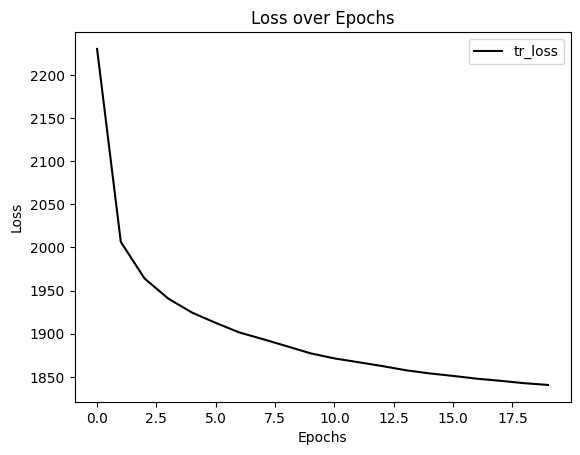

In [14]:
losses, best_loss = train_Vae(dataloader, N_epochs, model, Normal_loss, optimizer, b = 0.1, epoch_range=2)
Vae_graphs(losses, N_epochs)

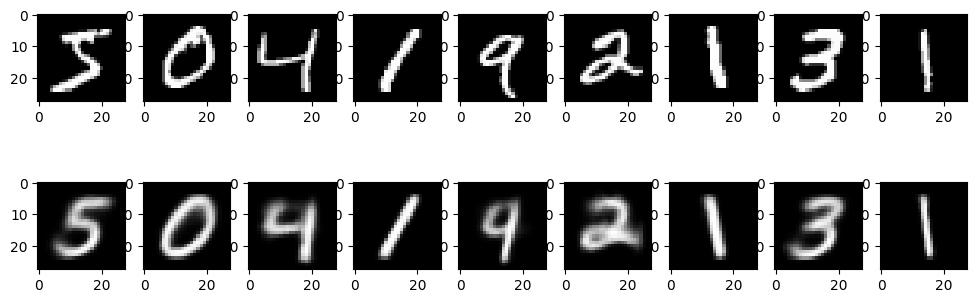

In [9]:
img_vs_recon(model, dataloader)

In [18]:
loader = get_random_sample_dataloader(datas,10)
scatter_3d(model,loader)

IndexError: index 2 is out of bounds for dimension 1 with size 2

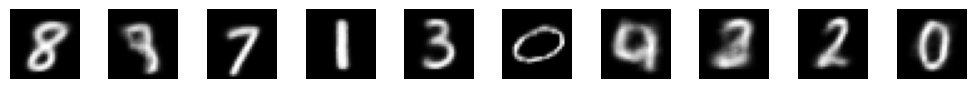

In [10]:
plot_generate(model, 3, 10)

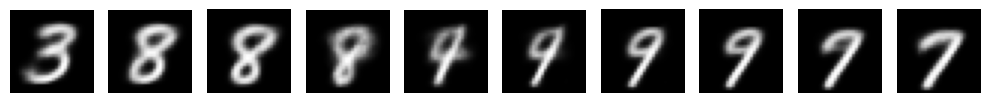

In [11]:
x = dataloader.dataset.data[7].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[15].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y)

-spazio latente a 50 dimensioni

In [12]:
model = Normal_VAE(300,50)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

Epoch: 2 | Loss: 1422.3103 | Time: 185.98
Epoch: 4 | Loss: 1271.2857 | Time: 185.27
Epoch: 6 | Loss: 1207.4944 | Time: 186.90
Epoch: 8 | Loss: 1176.5127 | Time: 182.75
Epoch: 10 | Loss: 1150.7064 | Time: 183.48
Epoch: 12 | Loss: 1137.7646 | Time: 183.01
Epoch: 14 | Loss: 1128.4817 | Time: 185.75
Epoch: 16 | Loss: 1121.6579 | Time: 183.38
Epoch: 18 | Loss: 1116.2242 | Time: 217.97
Epoch: 20 | Loss: 1112.0071 | Time: 194.70


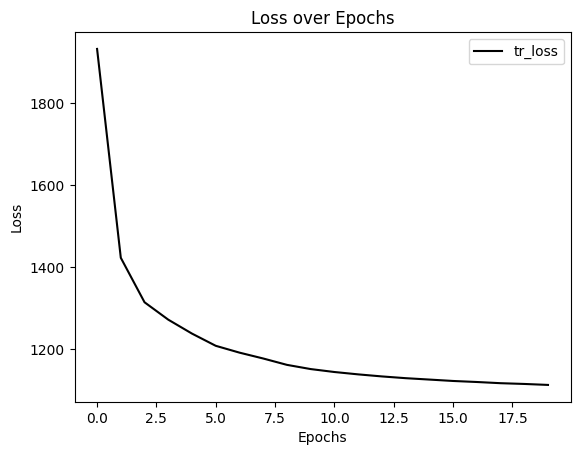

In [13]:
losses, best_loss = train_Vae(dataloader, N_epochs, model, Normal_loss, optimizer, b = 0.1, epoch_range=2)
Vae_graphs(losses, N_epochs)

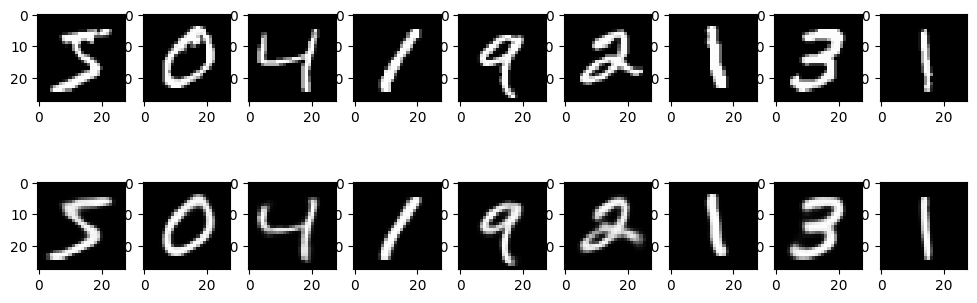

In [14]:
img_vs_recon(model, dataloader)

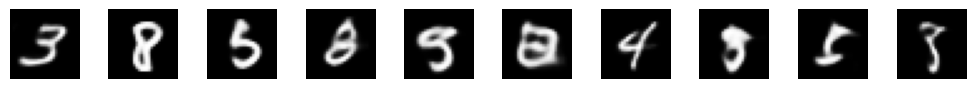

In [21]:
plot_generate(model, 50, 10)

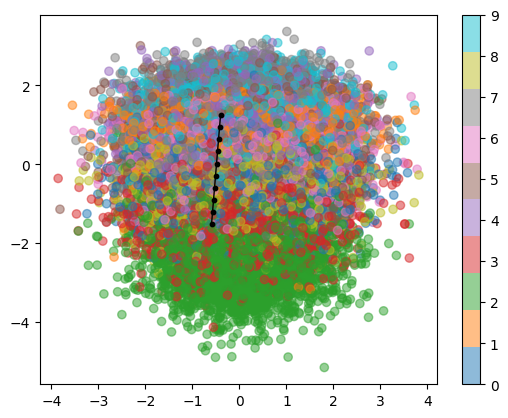

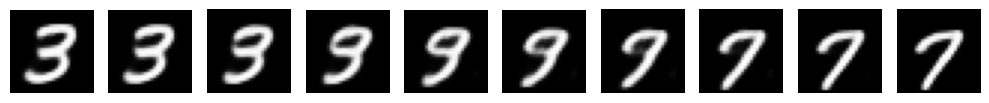

In [53]:
x = dataloader.dataset.data[7].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[15].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y)

In [6]:
model = Normal_VAE(300,50)
model.load_state_dict(torch.load('300_50_Normal_Vae.pth'))

<All keys matched successfully>

In [8]:
Zs = []
Ys = []
with torch.no_grad():
    for img, labels in tqdm(dataloader, desc='Encoding img'):
        img = img.to(device)
        mu, logv = model.encode(img)
        z = model.reparametrize(mu,logv)
        Zs.append(z.detach().cpu())
        Ys.append(labels.cpu())
Zs = torch.cat(Zs).numpy()
Ys = torch.cat(Ys).numpy()
Ys_subset = Ys[:2000]

Encoding img: 100%|██████████| 4000/4000 [00:34<00:00, 117.13it/s]


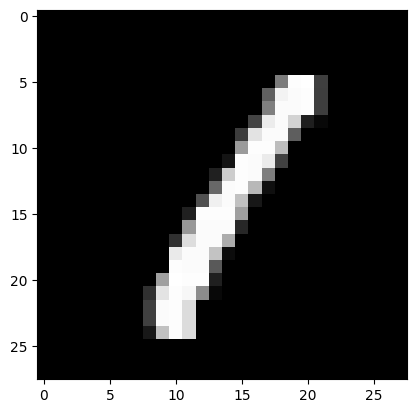

In [7]:
x = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0
plt.imshow(x[0,0].detach().numpy(), cmap='gray')

In [9]:
x = dataloader.dataset.data[1].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0

params1 = model.encode(x)
params2 = model.encode(y)

z1 = model.reparametrize(*params1)
z2 = model.reparametrize(*params2)

interpolated_z = torch.stack([ (1-alpha) * z1 + alpha * z2 for alpha in torch.linspace(0,1,steps = 15)]).to(next(model.parameters()).device)
interp_z = interpolated_z.squeeze(1)

In [10]:
Z_total = np.concatenate([Zs[:2000], interp_z.cpu().detach().numpy()], axis=0)
tsne = KernelPCA(n_components=2)
X_tsne_total = tsne.fit_transform(Z_total)
X_tsne_data = X_tsne_total[:2000]
X_tsne_interp = X_tsne_total[2000:]

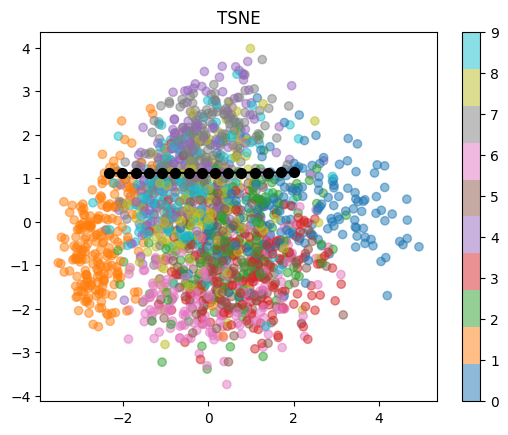

In [11]:
plt.scatter(X_tsne_data[:, 0], X_tsne_data[:, 1], c=Ys_subset, cmap='tab10', alpha=0.5)
plt.colorbar()
plt.plot(X_tsne_interp[:, 0], X_tsne_interp[:, 1], color='black')
plt.scatter(X_tsne_interp[:, 0], X_tsne_interp[:, 1], color='black', s=50, zorder=3)
plt.title('TSNE')
plt.show()

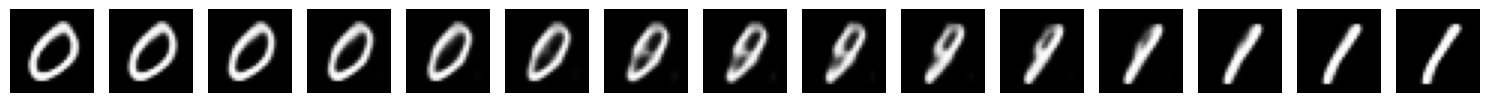

In [12]:
with torch.no_grad():
        decoded_img = model.decode(interpolated_z.squeeze(1))

fig, axes = plt.subplots(1,15, figsize=(15, 1.5))
for i in range(15):
    axes[i].imshow(decoded_img[i].squeeze().cpu(), cmap='grey')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Provo ora a utilizzzare 2 metodi per migliorare la risoluzione delle immagini generate con 2 metodi: perceptive loss e denoising autoencoder

-perceptive loss: allenamento del predittore

Epoch: 1 | Train Loss: 0.9672 | Train Accuracy: 74.1887 | Test Loss:0.3550 | Test Accuracy 89.0131 | Time: 9.95
Epoch: 2 | Train Loss: 0.3033 | Train Accuracy: 92.2476 | Test Loss:0.2545 | Test Accuracy 92.3259 | Time: 10.93
Epoch: 3 | Train Loss: 0.2071 | Train Accuracy: 95.1623 | Test Loss:0.1637 | Test Accuracy 94.8774 | Time: 11.01
Epoch: 4 | Train Loss: 0.1446 | Train Accuracy: 96.6647 | Test Loss:0.1118 | Test Accuracy 96.5882 | Time: 10.99
Epoch: 5 | Train Loss: 0.1081 | Train Accuracy: 97.8466 | Test Loss:0.0836 | Test Accuracy 97.4585 | Time: 10.79
Epoch: 6 | Train Loss: 0.0838 | Train Accuracy: 98.6979 | Test Loss:0.0674 | Test Accuracy 97.9727 | Time: 10.81
Epoch: 7 | Train Loss: 0.0689 | Train Accuracy: 99.1486 | Test Loss:0.0579 | Test Accuracy 98.3386 | Time: 10.99
Epoch: 8 | Train Loss: 0.0615 | Train Accuracy: 99.3890 | Test Loss:0.0512 | Test Accuracy 98.5067 | Time: 10.60
Epoch: 9 | Train Loss: 0.0490 | Train Accuracy: 99.7997 | Test Loss:0.0384 | Test Accuracy 99.001

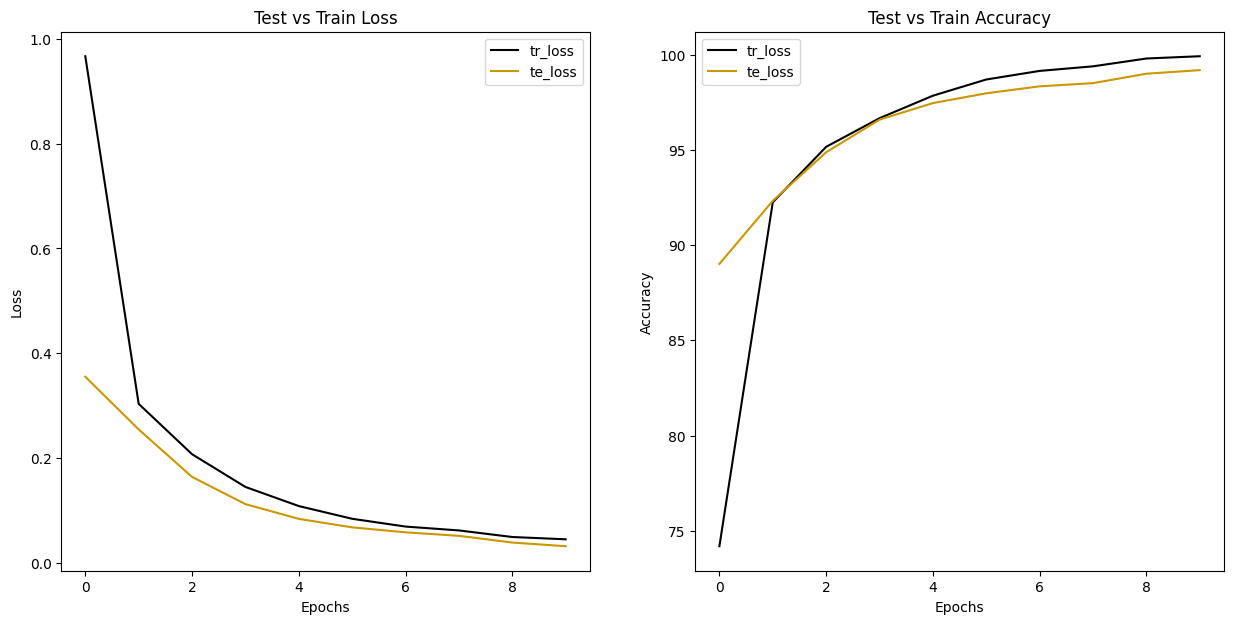

In [52]:
classificator = CNN_predictor()
N_Epochs = 10
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classificator.parameters(), lr=0.001, weight_decay=0.001)
tr_loss,tr_accs,te_loss,te_accs,_ = train_classificator(classificator, N_Epochs, trainloader, criterion, optimizer,testloader)
Predictor_graphs(tr_loss,tr_accs,te_loss,te_accs,N_Epochs)

99.18908227848101


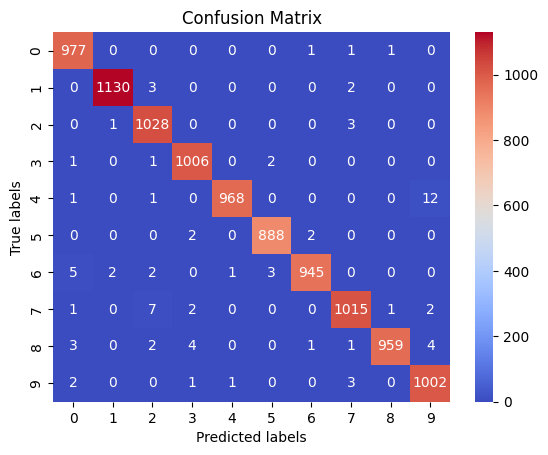

In [54]:
print(get_test_acc(classificator, testloader))
make_con_matrix(classificator, testloader)

In [9]:
classificator = CNN_predictor()
classificator.load_state_dict(torch.load('pre_trained_classificator.pth'))

<All keys matched successfully>

In [19]:
model = Normal_VAE(200,2)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [20]:
train_percept_Vae(dataloader= dataloader, N_epochs= N_epochs, model= model, criterion=perceptual_loss, optimizer=optimizer, predictor=classificator,b=0.1,layers=[1,2,3,4],scheduler=scheduler,other_criterion=Normal_loss,epoch_range=2 )

Epoch: 2 | Loss: 2211.5116 | Time: 273.83
Epoch: 4 | Loss: 2154.4289 | Time: 285.38
Epoch: 6 | Loss: 2127.5777 | Time: 305.55
Epoch: 8 | Loss: 2072.9391 | Time: 281.66
Epoch: 10 | Loss: 2062.5021 | Time: 453.13
Epoch: 12 | Loss: 2055.4753 | Time: 312.56
Epoch: 14 | Loss: 2054.3555 | Time: 276.36
Epoch: 16 | Loss: 2054.1657 | Time: 261.07
Epoch: 18 | Loss: 2054.0588 | Time: 263.59
Epoch: 20 | Loss: 2054.0014 | Time: 270.09


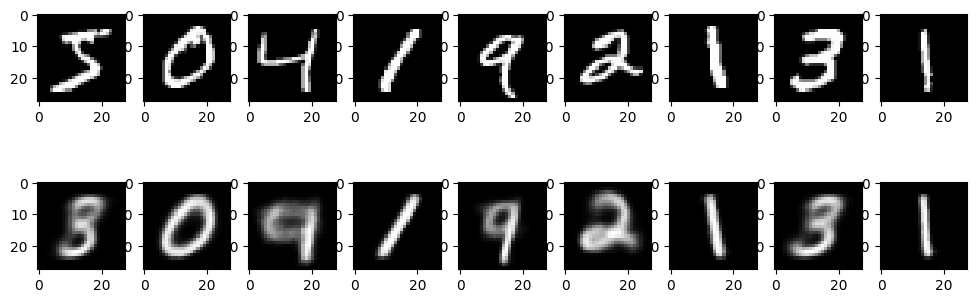

In [21]:
img_vs_recon(model, dataloader)

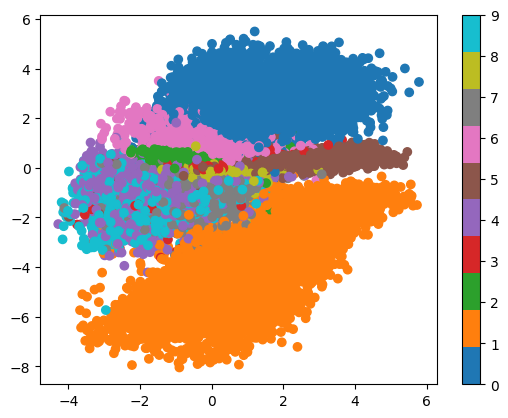

In [22]:
scatter(model,dataloader)

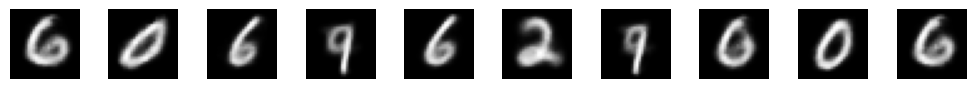

In [23]:
plot_generate(model, 2, 10)

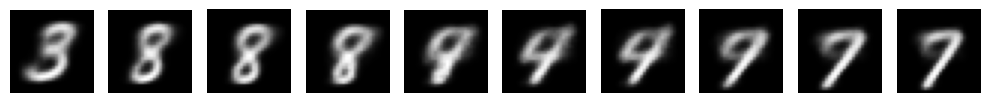

In [24]:
x = dataloader.dataset.data[7].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[15].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y)

-stesso ma con spazio a 3 dimensioni

In [30]:
model = Normal_VAE(200,3)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)

In [31]:
train_percept_Vae(dataloader= dataloader, N_epochs= N_epochs, model= model, criterion=perceptual_loss, optimizer=optimizer, predictor=classificator,b=0.1,layers=[1,2,3,4],scheduler=scheduler,other_criterion=Normal_loss,epoch_range=2 )

Epoch: 2 | Loss: 1983.0222 | Time: 361.94
Epoch: 4 | Loss: 1921.5638 | Time: 333.46
Epoch: 6 | Loss: 1892.1688 | Time: 293.47
Epoch: 8 | Loss: 1874.5762 | Time: 284.85
Epoch: 10 | Loss: 1862.7121 | Time: 369.29
Epoch: 12 | Loss: 1852.4147 | Time: 461.77
Epoch: 14 | Loss: 1843.1710 | Time: 378.36
Epoch: 16 | Loss: 1837.4908 | Time: 277.07
Epoch: 18 | Loss: 1831.1918 | Time: 273.78
Epoch: 20 | Loss: 1825.5648 | Time: 279.90


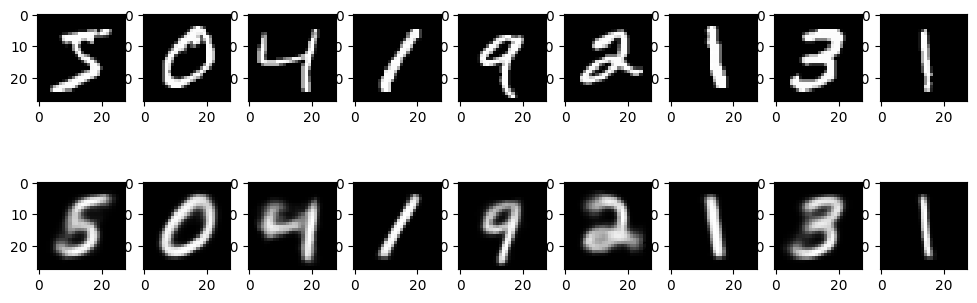

In [33]:
img_vs_recon(model, dataloader)

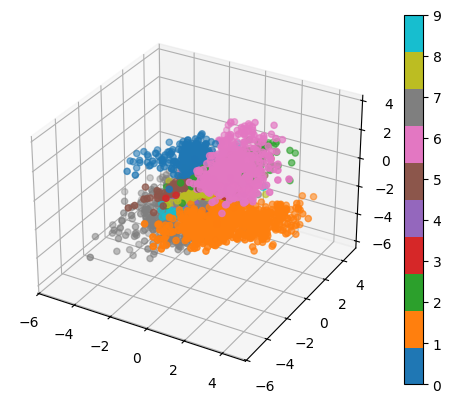

In [34]:
loader = get_random_sample_dataloader(datas,10)
scatter_3d(model,loader)

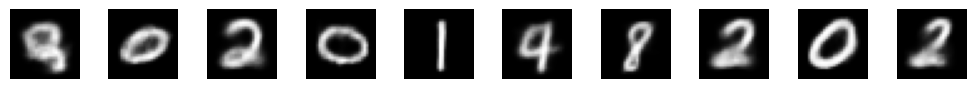

In [35]:
plot_generate(model, 3, 10)

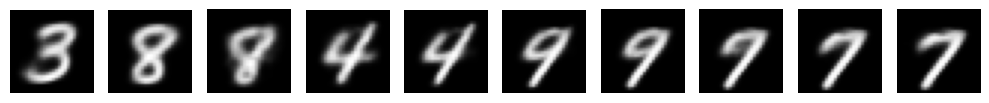

In [36]:
x = dataloader.dataset.data[7].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[15].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y)

La perceptive loss non porte miglioramenti

-provo ad usare un decoder più profondo

In [6]:
model = Normal_VAE_extended(200,2)
model.load_state_dict(torch.load('temporary_Vae.pth'))

<All keys matched successfully>

In [30]:
torch.save(model.state_dict(), '200_2_t_student_Vae.pth')

In [32]:
model = Normal_VAE_extended(200,2)
N_epochs = 30
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

Epoch: 2 | Loss: 2238.4643 | Time: 509.70
Epoch: 4 | Loss: 2145.2156 | Time: 511.78
Epoch: 6 | Loss: 2092.9950 | Time: 513.13
Epoch: 8 | Loss: 2068.7624 | Time: 517.41
Epoch: 10 | Loss: 2075.1879 | Time: 513.24
Epoch: 12 | Loss: 2054.3358 | Time: 513.53
Epoch: 14 | Loss: 2047.3256 | Time: 510.72
Epoch: 16 | Loss: 2021.1798 | Time: 513.00
Epoch: 18 | Loss: 2027.5185 | Time: 569.43
Epoch: 20 | Loss: 2014.6535 | Time: 640.26
Epoch: 22 | Loss: 2014.6156 | Time: 669.43
Epoch: 24 | Loss: 1959.1727 | Time: 677.45
Epoch: 26 | Loss: 1949.2517 | Time: 680.44
Epoch: 28 | Loss: 1942.6052 | Time: 735.75
Epoch: 30 | Loss: 1937.9684 | Time: 835.67


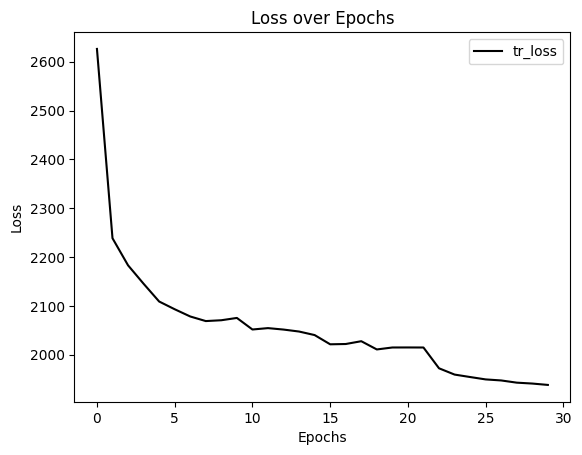

In [33]:
losses, best_loss = train_Vae(dataloader, N_epochs, model, Normal_loss, optimizer, b = 0.5, epoch_range=2, scheduler=scheduler)
Vae_graphs(losses, N_epochs)

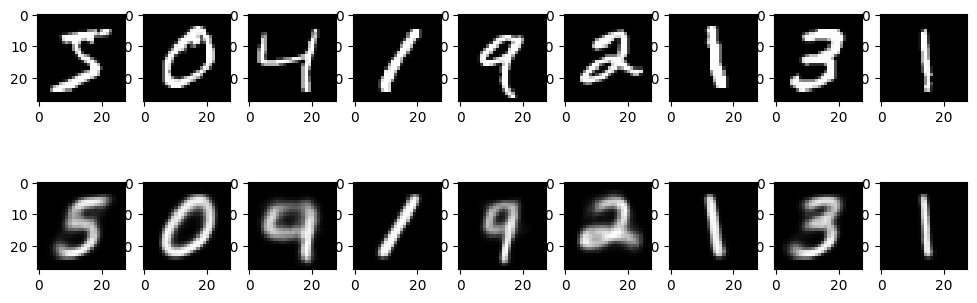

In [18]:
img_vs_recon(model, dataloader)

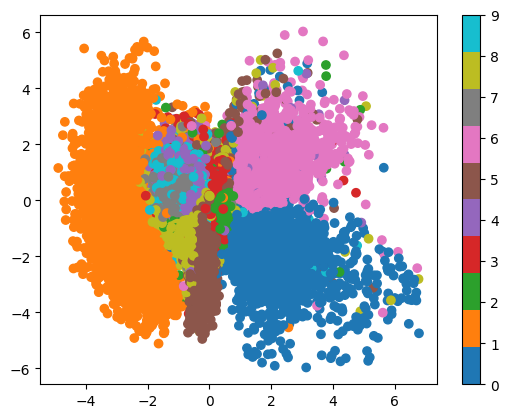

In [19]:
scatter(model,dataloader)

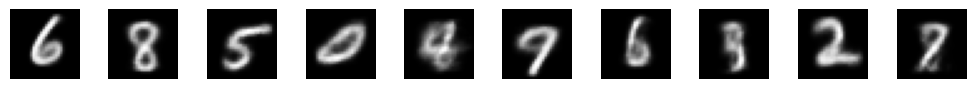

In [20]:
plot_generate(model, 2, 10)

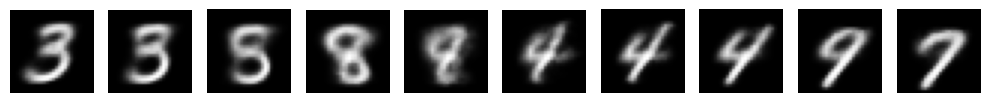

In [21]:
x = dataloader.dataset.data[7].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[15].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y)

Nemmeno rendere più complessi decoder e encoder aiuta a migliorare la risoluzione. proviamo quindi un denoising autoencoder

In [7]:
model = Normal_VAE(200,2)
model.load_state_dict(torch.load('200-2_Normal_Vae.pth'))

<All keys matched successfully>

In [ ]:
denoiser = Denoising_AE()
N_epochs = 20
optimizer = torch.optim.Adam(denoiser.parameters(), lr= 0.001)
noisy_data = []
labels = []
with torch.no_grad():
    for batch,lab in dataloader:
        args = model(batch)
        noisy_data.append(args[0])
        labels.append(lab)

noisy_data = torch.cat(noisy_data, dim=0)
labels = torch.cat(labels, dim=0)


noisy_dataset = torch.utils.data.TensorDataset(noisy_data, labels)
noisy_loader = torch.utils.data.DataLoader(noisy_dataset, batch_size=15)

-provo ora modeli con una distribuzione t-student come prior 

-- spazio latente 2-dimensionale

In [6]:
model = T_student_VAE(200, z_dim=2)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [7]:
model.load_state_dict(torch.load('200_2_t_student_Vae.pth'))

<All keys matched successfully>

batch: 4000it [59:46,  1.12it/s]
batch: 4000it [59:15,  1.12it/s]


Epoch: 2 | Loss: 1192.4013 | Time: 7141.86


batch: 4000it [59:06,  1.13it/s]
batch: 4000it [58:50,  1.13it/s]


Epoch: 4 | Loss: 1061.5077 | Time: 7077.46


batch: 4000it [58:48,  1.13it/s]
batch: 4000it [59:06,  1.13it/s]


...

Epoch: 16 | Loss: 938.6614 | Time: 7455.03


batch: 4000it [56:08,  1.19it/s]
batch: 4000it [55:52,  1.19it/s]


Epoch: 18 | Loss: 934.9010 | Time: 6720.17


batch: 4000it [55:59,  1.19it/s]
batch: 4000it [1:00:09,  1.11it/s]


Epoch: 20 | Loss: 930.9124 | Time: 6969.46


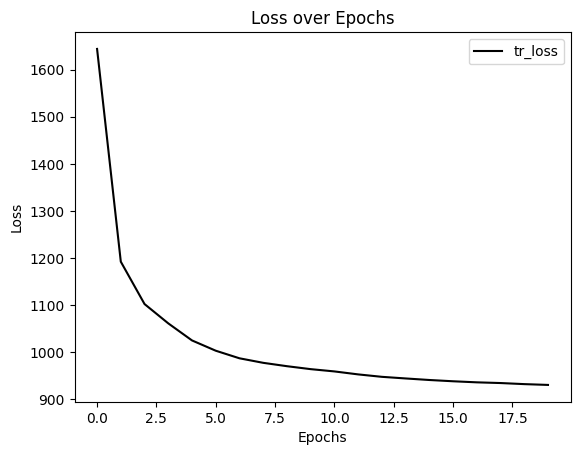

In [89]:
losses, best_loss = train_Vae(dataloader, N_epochs, model, t_di_student_loss, optimizer, b = 0.1, epoch_range=2, scheduler=scheduler)
Vae_graphs(losses, N_epochs)

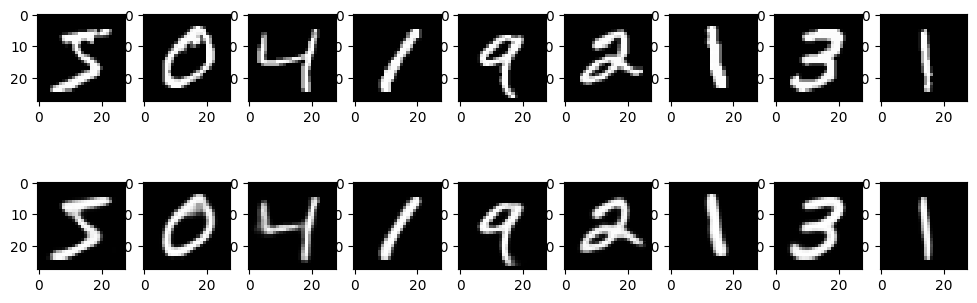

In [90]:
img_vs_recon(model, dataloader)

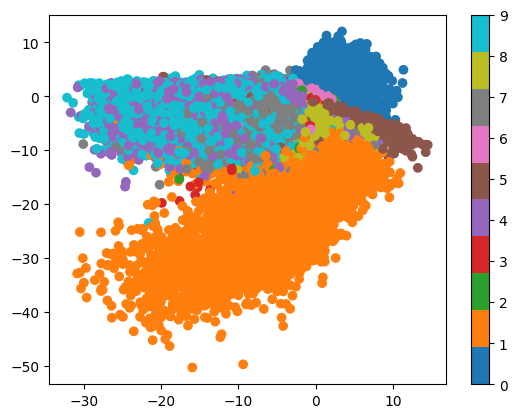

In [8]:
scatter(model,dataloader)

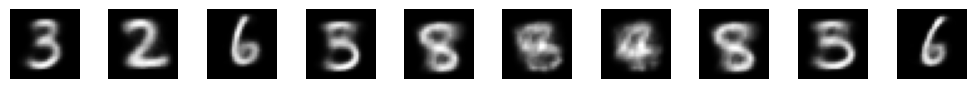

In [10]:
plot_generate(model, 2, 10)

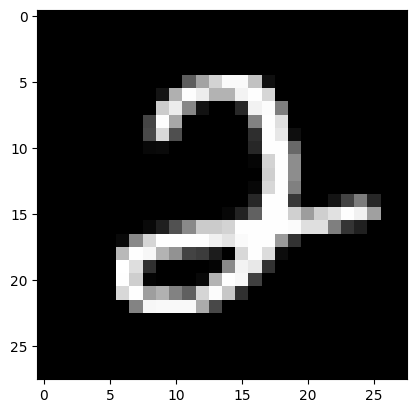

In [15]:
x = dataloader.dataset.data[16].unsqueeze(0).unsqueeze(0).float() / 255.0
plt.imshow(x[0,0].detach().numpy(), cmap='gray')

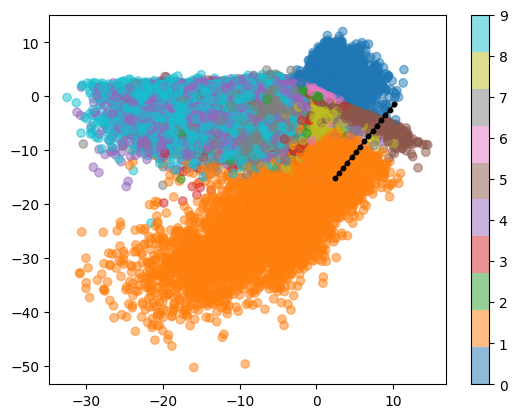

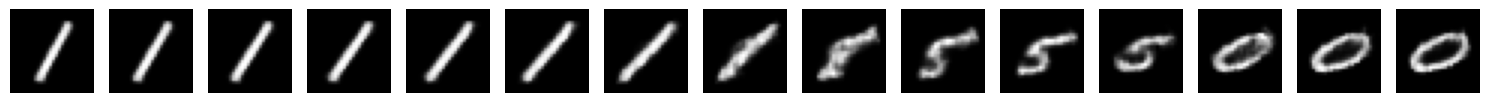

In [43]:
x = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[16].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation(model, x, y, 15)

--spazio latente tri dimensionale

In [34]:
model1 = T_student_VAE(300, z_dim=50)
N_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr= 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [35]:
model1.load_state_dict(torch.load('300_50_t_student_vae.pth'))

<All keys matched successfully>

In [33]:
torch.save(model1.state_dict(), '300_50_t_student_vae.pth')

Epoch: 2 | Loss: 2185.0199 | Time: 478.54
Epoch: 4 | Loss: 2123.9634 | Time: 646.64
Epoch: 6 | Loss: 2097.6205 | Time: 889.44
Epoch: 8 | Loss: 2077.6034 | Time: 621.15
Epoch: 10 | Loss: 2065.3143 | Time: 617.41
Epoch: 12 | Loss: 2056.7010 | Time: 705.18
Epoch: 14 | Loss: 2048.5687 | Time: 652.61
Epoch: 16 | Loss: 2043.5086 | Time: 613.92
Epoch: 18 | Loss: 2039.5680 | Time: 626.06
Epoch: 20 | Loss: 2034.3415 | Time: 660.49


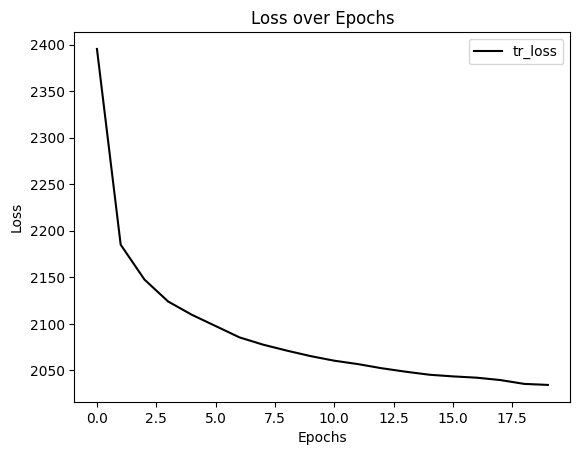

In [ ]:
losses, best_loss = train_Vae(dataloader, N_epochs, model, t_di_student_loss, optimizer, b = 0.1, epoch_range=2, scheduler=scheduler)
Vae_graphs(losses, N_epochs)

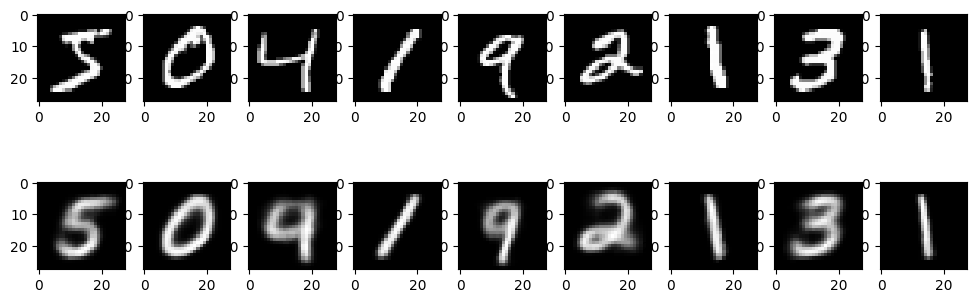

In [8]:
img_vs_recon(model, dataloader)

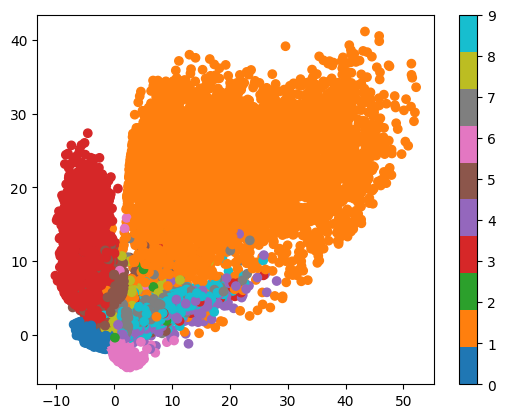

In [9]:
scatter(model,dataloader)

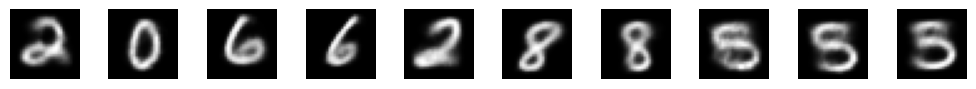

In [36]:
plot_generate(model, 2, 10)

In [42]:
Zs = []
Ys = []
with torch.no_grad():
    for img, labels in tqdm(dataloader, desc='Encoding img'):
        img = img.to(device)
        a, b, c = model1.encode(img)
        z = model1.reparametrize(a,b,c)
        Zs.append(z.detach().cpu())
        Ys.append(labels.cpu())
Zs = torch.cat(Zs).numpy()
Ys = torch.cat(Ys).numpy()
Ys_subset = Ys[:2000]

Encoding img: 100%|██████████| 4000/4000 [00:46<00:00, 86.66it/s] 


In [44]:
x = dataloader.dataset.data[1].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0

params1 = model1.encode(x)
params2 = model1.encode(y)

z1 = model1.reparametrize(*params1)
z2 = model1.reparametrize(*params2)

interpolated_z = torch.stack([ (1-alpha) * z1 + alpha * z2 for alpha in torch.linspace(0,1,steps = 15)]).to(next(model1.parameters()).device)
interp_z = interpolated_z.squeeze(1)

In [45]:
# Unisci i 2000 punti + gli interpolati
Z_total = np.concatenate([Zs[:2000], interp_z.cpu().detach().numpy()], axis=0)

# Rifai t-SNE
tsne = TSNE(n_components=2)
X_tsne_total = tsne.fit_transform(Z_total)

# Suddividi
X_tsne_data = X_tsne_total[:2000]
X_tsne_interp = X_tsne_total[2000:]

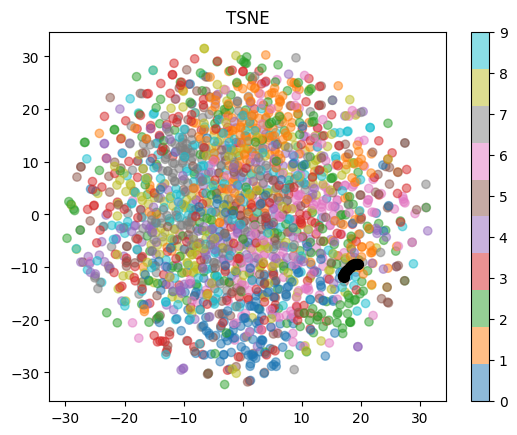

In [46]:
plt.scatter(X_tsne_data[:, 0], X_tsne_data[:, 1], c=Ys_subset, cmap='tab10', alpha=0.5)
plt.colorbar()
plt.plot(X_tsne_interp[:, 0], X_tsne_interp[:, 1], color='black')
plt.scatter(X_tsne_interp[:, 0], X_tsne_interp[:, 1], color='black', s=50, zorder=3)
plt.title('TSNE')
plt.show()

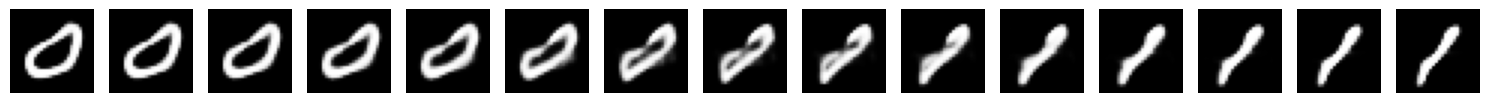

In [48]:
with torch.no_grad():
        decoded_img = model1.decode(interpolated_z.squeeze(1))

fig, axes = plt.subplots(1,15, figsize=(15, 1.5))
for i in range(15):
    axes[i].imshow(decoded_img[i].squeeze().cpu(), cmap='grey')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [56]:
model = GumbelVAE()
N_epochs = 40
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

batch: 4000it [00:43, 92.69it/s] 
batch: 4000it [00:41, 96.52it/s] 


Epoch: 2 | Loss: 2854.1173 | Time: 84.62


batch: 4000it [00:43, 92.03it/s] 
batch: 4000it [00:44, 89.80it/s] 


Epoch: 4 | Loss: 2807.8660 | Time: 88.04


batch: 4000it [00:44, 90.59it/s] 
batch: 4000it [00:47, 84.21it/s] 


...

Epoch: 36 | Loss: 2173.6813 | Time: 110.54


batch: 4000it [00:52, 76.71it/s]
batch: 4000it [00:52, 76.71it/s]


Epoch: 38 | Loss: 2150.2932 | Time: 104.31


batch: 4000it [00:51, 77.40it/s]
batch: 4000it [00:52, 76.54it/s] 


Epoch: 40 | Loss: 2133.3107 | Time: 103.95


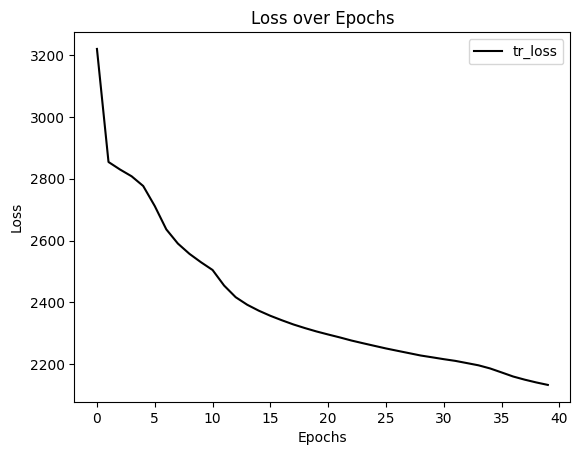

In [57]:
losses, best_loss = train_G_Vae(dataloader, N_epochs, model, gumbel_vae_loss, optimizer, epoch_range=2, scheduler=scheduler)
Vae_graphs(losses, N_epochs)

In [58]:
torch.save(model.state_dict(),'Gumball_VAE.pth')

In [59]:
model.load_state_dict(torch.load('Gumball_VAE.pth'))

<All keys matched successfully>

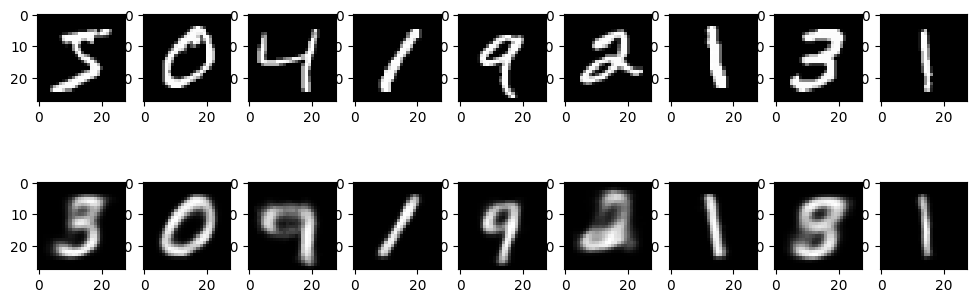

In [60]:
img_vs_recon(model, dataloader)

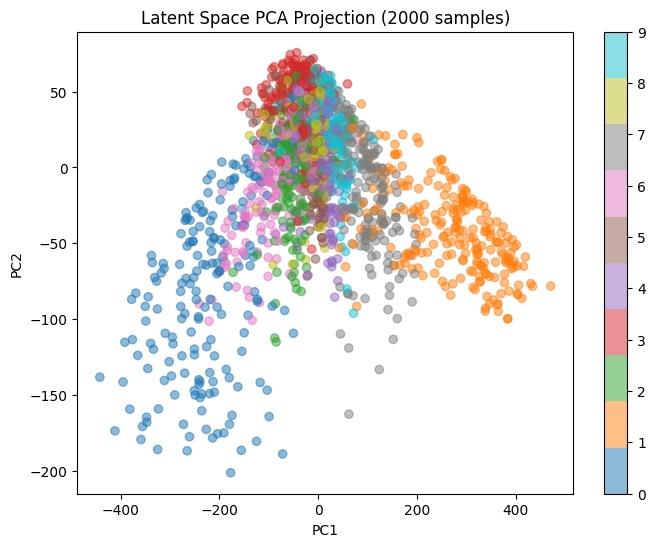

In [61]:
scatter_G(model,dataloader)

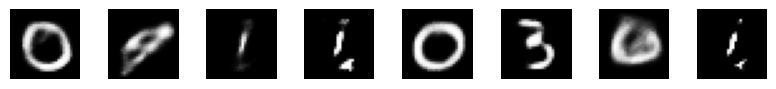

In [62]:
plot_generate(model, 100, 8)

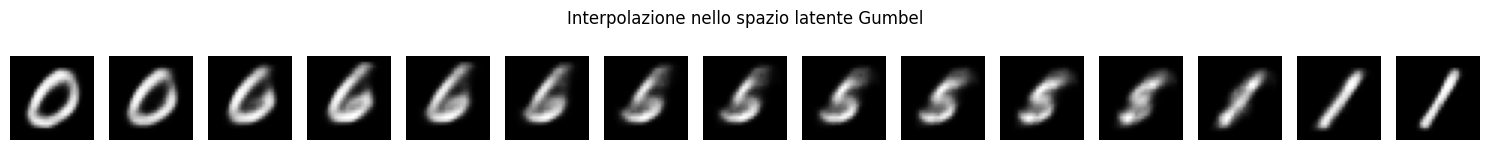

In [ ]:
x = dataloader.dataset.data[1].unsqueeze(0).unsqueeze(0).float() / 255.0
y = dataloader.dataset.data[3].unsqueeze(0).unsqueeze(0).float() / 255.0
plt_interpolation_G(model, x, y, dataloader, n_step=15)

In [7]:
%matplotlib widget

In [8]:
model = Normal_VAE(200,2)
model.load_state_dict(torch.load('200_2_Normal_VAE.pth'))

<All keys matched successfully>

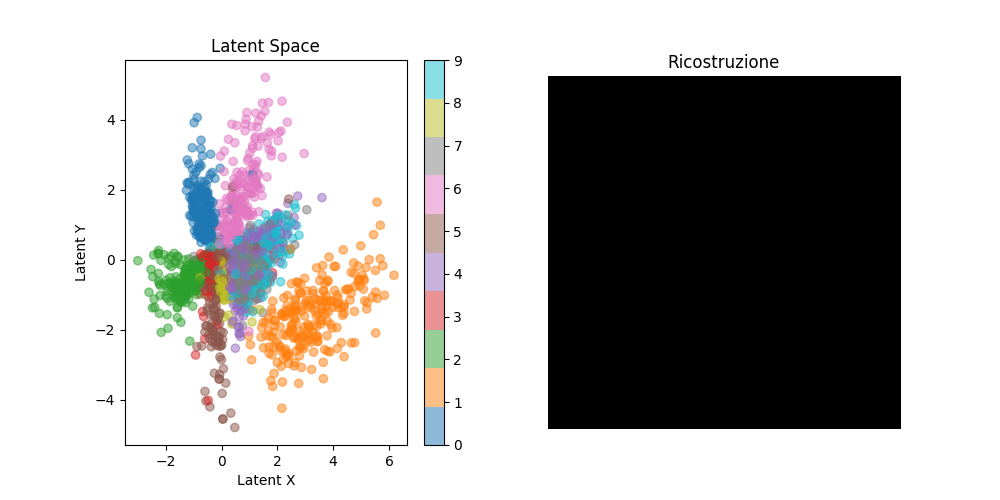

In [9]:
interactive_scatter_(model, dataloader)

In [10]:
model2 = T_student_VAE(200,h_dim=200,z_dim=2)
model2.load_state_dict(torch.load('200_2_t_student_Vae.pth'))

<All keys matched successfully>

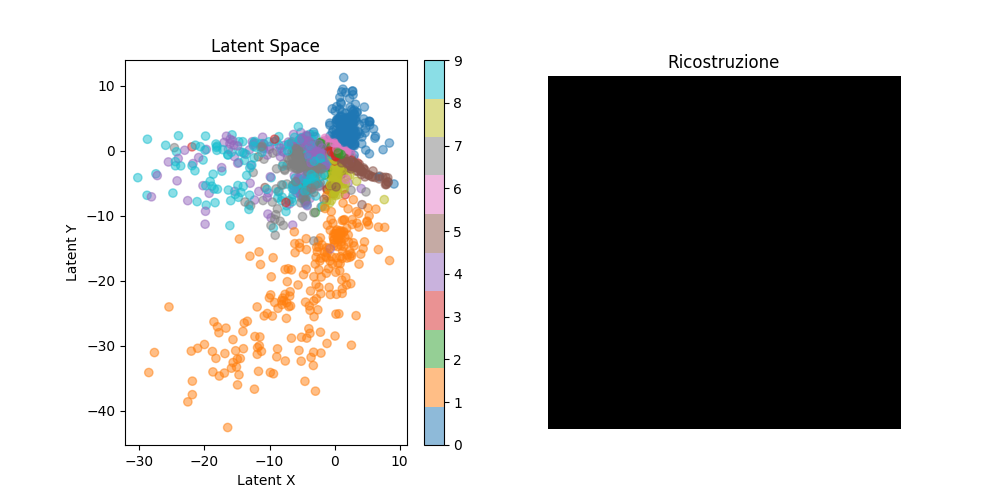

In [11]:
interactive_scatter_(model2, dataloader)